# Minimize a nonlinear function of two variables with an equality constraint

Do imports.

In [15]:
import numpy as np
from qpsolvers import solve_problem, Problem
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
import sympy as sym

%matplotlib widget

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)

Suppose we want to minimize the same function

$$ f(x) = (a - x_1)^2 + b (x_2 - x_1^2)^2 $$

as before (with parameters $a=1$ and $b=1$), but now subject to the constraint that

$$ g(x) = \begin{bmatrix} (x_1 - c_1)^2 + (x_2 - c_2)^2 - r^2 \end{bmatrix} = 0 $$

with parameters $c_1=0$, $c_2=0$, and $r=1$.
Note that $f$ maps $x$ to a scalar but that $g$ maps $x$ to a vector. That vector has only one element in this particular example, because there is only one equality constraint. If there were $m$ equality constraints, $g$ would map to a vector with $m$ elements. We can index $g$ to refer to any particular element (i.e., to any particular equality constraint). For example, we can write

$$ g_1(x) = (x_1 - c_1)^2 + (x_2 - c_2)^2 - r^2. $$

Again, it is important to emphasize that $g$ is vector-valued, while $g_1$ (the first element of $g$) is scalar-valued. In the following code cell, we define the cost $f(x)$, the constraint $g(x)$, the gradient $\nabla f(x)$ of the cost, and the Jacobian $\mathbf{J}g(x)$ of the constraint.

In [16]:
# Parameters
params = {
    'a': 1,
    'b': 1,
    'c_x1': 0,
    'c_x2': 0,
    'c_r': 1,
}

# Variables
x1, x2 = sym.symbols('x1, x2')

# Cost
f_sym = (params['a'] - x1)**2 + params['b'] * (x2 - x1**2)**2
f_batch = sym.lambdify([x1, x2], f_sym)
f = lambda x: f_batch(*x)

# Constraint (equality)
g_sym = sym.Matrix([(x1 - params['c_x1'])**2 + (x2 - params['c_x2'])**2 - params['c_r']**2])
g_batch = sym.lambdify([x1, x2], g_sym)
g = lambda x: g_batch(*x).flatten()

# Gradient of cost
f_x_sym = sym.simplify(sym.Matrix([f_sym]).jacobian([x1, x2]).T)
f_x_batch = sym.lambdify([x1, x2], f_x_sym)
f_x = lambda x: f_x_batch(*x).flatten()

# Jacobian of constraint (row i of this matrix is the transpose
# of the gradient of g_i(x) with respect to x)
g_x_sym = sym.simplify(g_sym.jacobian([x1, x2]))
g_x_batch = sym.lambdify([x1, x2], g_x_sym)
g_x = lambda x: g_x_batch(*x)

Show by example that $\nabla f(x^\ast)$ and $\nabla g_1(x^\ast)$ are *parallel* at any point $x^\ast$ that locally minimizes or maximizes $f$ subject to the constraint $g_1$.

SelectionSlider(description='θ', layout=Layout(width='500px'), options=(('0.0000', np.float64(0.0)), ('0.0126'…

LOCAL MINIMA AND MAXIMA
 theta = 0.6296 : x = [ 0.81,  0.59]
 theta = 3.4153 : x = [-0.96, -0.27]
 theta = 5.2558 : x = [ 0.52, -0.86]
 theta = 5.7114 : x = [ 0.84, -0.54]


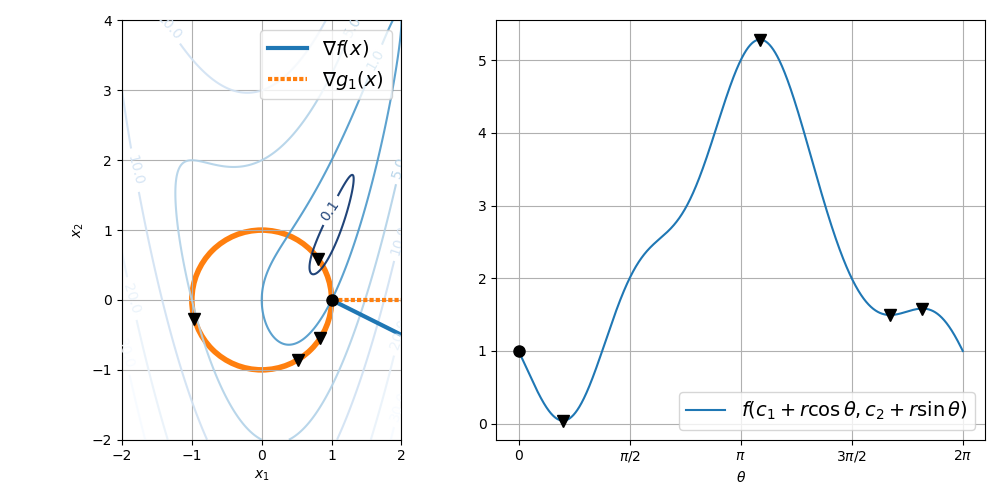

In [17]:
# Close any previously opened figures before creating a new one
# (with matplotlib widget, we get warnings about memory use)
plt.close('Gradients are parallel at local minima or maxima')

# Figure
fig, (ax2d, axtheta) = plt.subplots(1, 2, figsize=(10, 5), num='Gradients are parallel at local minima or maxima')

# Cost
x1_bnds = [-2, 2]
x2_bnds = [-2, 4]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='Blues_r', alpha=0.9)
ax2d.clabel(CS, fontsize=10)

# Constraint circle
circ = plt.Circle((params['c_x1'], params['c_x2']), params['c_r'], color='C1', fill=False, linewidth=4)
ax2d.add_patch(circ)

# Constrained cost curve
thetas = np.linspace(0, 2 * np.pi, 10000)
x1s = params['c_x1'] + params['c_r'] * np.cos(thetas)
x2s = params['c_x2'] + params['c_r'] * np.sin(thetas)
fs = f_batch(x1s, x2s)
axtheta.plot(thetas, fs, label=r'$f(c_1 + r \cos\theta, c_2 + r \sin\theta)$')

# Constrained minima and maxima dots
i_max = np.where((fs[1:-1] > fs[:-2]) & (fs[1:-1] > fs[2:]))[0] + 1
i_min = np.where((fs[1:-1] < fs[:-2]) & (fs[1:-1] < fs[2:]))[0] + 1
i_ext = np.concatenate([i_min, i_max])
ax2d.plot(
    params['c_x1'] + params['c_r'] * np.cos(thetas[i_ext]),
    params['c_x2'] + params['c_r'] * np.sin(thetas[i_ext]),
    'v', color='k', markersize=8,
)
axtheta.plot(thetas[i_ext], fs[i_ext], 'v', color='k', markersize=8)

# Function to get x, grad_f(x), grad_g(x) at a point x
# that is an angle theta around the constraint circle
def get_data(theta):
    x1i = params['c_x1'] + params['c_r'] * np.cos(theta)
    x2i = params['c_x2'] + params['c_r'] * np.sin(theta)
    grad_f = f_x([x1i, x2i])
    grad_g = g_x([x1i, x2i])[0]
    return x1i, x2i, grad_f, grad_g

# Mutable artists we'll update in-place
theta0 = 0.0
x1i, x2i, grad_f, grad_g = get_data(theta0)
line_f,  = ax2d.plot([x1i, x1i + grad_f[0]], [x2i, x2i + grad_f[1]],
                     color='C0', linewidth=3, label=r'$\nabla f(x)$')
line_g,  = ax2d.plot([x1i, x1i + grad_g[0]], [x2i, x2i + grad_g[1]],
                     color='C1', linewidth=3, dashes=[1, .5], label=r'$\nabla g_1(x)$')
dot_2d,  = ax2d.plot(x1i, x2i, 'o', color='black', markersize=8, zorder=5)
dot_theta, = axtheta.plot(theta0, f([x1i, x2i]), 'o', color='black', markersize=8, zorder=5)

# Clean up axes
ax2d.legend(fontsize=14, loc='upper right')
ax2d.set_aspect('equal')
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
axtheta.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axtheta.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
axtheta.set_xlabel(r'$\theta$')
axtheta.grid()
axtheta.legend(fontsize=14)
fig.tight_layout()

# Function to update plots for a give value of theta
def update(theta):
    x1i, x2i, grad_f, grad_g = get_data(theta)
    line_f.set_data([x1i, x1i + grad_f[0]], [x2i, x2i + grad_f[1]])
    line_g.set_data([x1i, x1i + grad_g[0]], [x2i, x2i + grad_g[1]])
    dot_2d.set_data([x1i], [x2i])
    dot_theta.set_data([theta], [f([x1i, x2i])])
    
    # Redraw only what changed (fast, avoids flickering)
    fig.canvas.draw_idle()

# Use a selection slider to make sure that the local minima and
# maxima can be selected exactly
theta_uniform = np.linspace(0, 2 * np.pi, 500, endpoint=False)
theta_vals = np.unique(np.concatenate([theta_uniform, sorted(thetas[i_ext])]))
slider = widgets.SelectionSlider(
    options=[('{:6.4f}'.format(v), v) for v in theta_vals],
    value=theta_vals[0],
    description='θ',
    continuous_update=True,
    layout=widgets.Layout(width='500px'),
)

# Connect slider to callbacka and display
slider.observe(lambda change: update(change['new']), names='value')
display(slider)

# Show local minima and maxima
print('LOCAL MINIMA AND MAXIMA')
for theta in sorted(thetas[i_ext]):
    x1i, x2i, grad_f, grad_g = get_data(theta)
    print(f' theta = {theta:6.4f} : x = [{x1i:5.2f}, {x2i:5.2f}]')

Define the **Lagrangian function**

$$ L(x, \lambda) = f(x) + \lambda^\top g(x) $$

and compute both its gradient $\nabla_x L(x, \lambda)$ and its hessian $\mathbf{H}_x L(x, \lambda)$ with respect to $x$.

In [18]:
# Lagrangian
l1 = sym.symbols('lambda_1')
L_sym = f_sym + sym.Matrix([l1]).dot(g_sym)
L = lambda x, l: sym.lambdify([x1, x2, l1], L_sym)(*x, *l)

# Gradient of Lagrangian with respect to x
L_x_sym = sym.Matrix([L_sym]).jacobian([x1, x2]).T
L_x_batch = sym.lambdify([x1, x2, l1], L_x_sym)
L_x = lambda x, l: L_x_batch(*x, *l)

# Hessian of Lagrangian with respect to x
L_xx_sym = L_x_sym.jacobian([x1, x2])
L_xx_batch = sym.lambdify([x1, x2, l1], L_xx_sym)
L_xx = lambda x, l: L_xx_batch(*x, *l)

# Display
display(Markdown(r'$L(x, \lambda)' + f' = {sym.latex(L_sym)}$'))
display(Markdown(r'$\nabla_x L(x, \lambda)' + f' = {sym.latex(L_x_sym)}$'))
display(Markdown(r'$\mathbf{H}_{x} L(x, \lambda)' + f' = {sym.latex(L_xx_sym)}$'))

$L(x, \lambda) = \lambda_{1} \left(x_{1}^{2} + x_{2}^{2} - 1\right) + \left(1 - x_{1}\right)^{2} + \left(- x_{1}^{2} + x_{2}\right)^{2}$

$\nabla_x L(x, \lambda) = \left[\begin{matrix}2 \lambda_{1} x_{1} - 4 x_{1} \left(- x_{1}^{2} + x_{2}\right) + 2 x_{1} - 2\\2 \lambda_{1} x_{2} - 2 x_{1}^{2} + 2 x_{2}\end{matrix}\right]$

$\mathbf{H}_{x} L(x, \lambda) = \left[\begin{matrix}2 \lambda_{1} + 12 x_{1}^{2} - 4 x_{2} + 2 & - 4 x_{1}\\- 4 x_{1} & 2 \lambda_{1} + 2\end{matrix}\right]$

Confirm the equivalence of the "root-finding" and "sequential quadratic programming" interpretations of the Newton step.

In [ ]:
# Initial guess
x = np.array([-1., 4.])
l = np.array([2.]) # <-- for testing, it is important for this to be non-zero
res = [
    np.linalg.norm(L_x(x, l), np.inf),
    np.linalg.norm(g(x), np.inf),
]

#########################
# ROOT-FINDING

A = np.block([[L_xx(x, l),    g_x(x).T],
              [g_x(x),        np.zeros(len(l))]])
b = - np.concatenate([f_x(x), g(x)])
sol = np.linalg.solve(A, b)
p_x_rtf = sol[:len(x)]
p_l_rtf = sol[len(x):] - l

with np.printoptions(precision=8):
    print('SOLUTION BY ROOT-FINDING')
    print(f' p_x = {p_x_rtf}')
    print(f' p_l = {p_l_rtf}')

#
#########################

print('')

#########################
# SQP

problem = Problem(P=L_xx(x, l), q=L_x(x,l), A=g_x(x), b=-g(x))
solution = solve_problem(problem, solver='proxqp', eps_abs=1e-8)
p_x_sqp = solution.x
p_l_sqp = solution.y

with np.printoptions(precision=8):
    print('SOLUTION BY SQP')
    print(f' p_x = {p_x_sqp}')
    print(f' p_l = {p_l_sqp}')

print('')

problem = Problem(P=L_xx(x, l), q=f_x(x), A=g_x(x), b=-g(x))
solution = solve_problem(problem, solver='proxqp', eps_abs=1e-8)
p_x_sqp2 = solution.x
p_l_sqp2 = solution.y - l

with np.printoptions(precision=8):
    print('SOLUTION BY SQP')
    print(f' p_x = {p_x_sqp2}')
    print(f' p_l = {p_l_sqp2}')

#
#########################

assert(np.allclose(p_x_rtf, p_x_sqp))
assert(np.allclose(p_l_rtf, p_l_sqp))
assert(np.allclose(p_x_sqp, p_x_sqp2))
assert(np.allclose(p_l_sqp, p_l_sqp2))

SOLUTION BY ROOT-FINDING
 p_x = [ 0.34285714 -1.91428571]
 p_l = [-1.48571429]

SOLUTION BY SQP
 p_x = [ 0.34285714 -1.91428571]
 p_l = [-1.48571429]

SOLUTION BY SQP
 p_x = [ 0.34285714 -1.91428571]
 p_l = [-1.48571429]


Define a function that checks if a candidate pair $(\widehat{a}, \widehat{b})$ is *dominated* by every pair in
$$
\{ (a_1, b_1), \dotsc, (a_n, b_n) \}.
$$
What it means for $(\widehat{a}, \widehat{b})$ to be dominated by $(a_i, b_i)$ is that $a_i \leq \widehat{a}$ and $b_i \leq \widehat{b}$. See Definition 15.2 of Nocedal and Wright (Numerical Optimization).

In [20]:
# Define function
def is_dominated(candidate_pair, pairs, verbose=False):
    """
    Returns True if candidate_pair is dominated by every pair in
    pairs, and False otherwise.
    """
    assert(len(candidate_pair) == 2)
    a_hat, b_hat = candidate_pair
    for pair in pairs:
        a, b = pair
        if (a <= a_hat) and (b <= b_hat):
            if verbose:
                print(f'    ({a:6.3e}, {b:6.3e}) dominates ({a_hat:6.3e}, {b_hat:6.3e})')
            return True
    return False

# Test function
assert(is_dominated([10., 0.], [[5., 0.], [15., 0.]], verbose=True))
assert(not is_dominated([1., 0.], [[5., 0.], [15., 0.]], verbose=True))
assert(not is_dominated([1., 1.], [[3., 2.], [2., 3.]], verbose=True))
assert(not is_dominated([1., 4.], [[3., 2.], [2., 3.]], verbose=True))
assert(is_dominated([4., 4.], [[3., 2.], [2., 3.]], verbose=True))

    (5.000e+00, 0.000e+00) dominates (1.000e+01, 0.000e+00)
    (3.000e+00, 2.000e+00) dominates (4.000e+00, 4.000e+00)


Solve full problem.

In [21]:
# Choose initial guess and compute cost and residual
x = np.array([-1., 4.])
l = np.array([0.])
res = [
    np.linalg.norm(L_x(x, l), np.inf),
    np.linalg.norm(g(x), np.inf),
]
cost = f(x)

# Create log to keep track of convergence
log = {
    'x': [x],
    'res': [res],
    'cost': [cost],
}

# Create list of pairs for filter method
pairs = [[f(x), np.linalg.norm(g(x), np.inf)]]

# Choose parameters
max_iters = 500
max_inner_iters = 10
tol = 1e-8
rho = 0.5
delta = 1e-6
omega = 10.

# Iterate
alpha = None
H = None
mu = None
success = False
for i in range(max_iters):
    # Show progress
    mu_str = f' : mu = {mu:.2e}' if mu is not None else ''
    alpha_str = f' : alpha = {alpha:.2e}' if alpha is not None else ''
    print(f'{i:3d} : |L_x| = {res[0]:11.8f} : |g| = {res[1]:11.8f} : f = {cost:7.4f}' + mu_str + alpha_str)

    # Check stopping condition (residuals)
    if (res[0] < tol) and (res[1] < tol):
        success = True
        if i == 0:
            print(f'success (initial guess satisfies necessary conditions for optimality)')
        else:
            print(f'success (converged at iteration {i})')
        break
    
    # Choose descent direction (Newton step with regularization)
    L_xx_val = L_xx(x, l)
    f_x_val = f_x(x)
    g_x_val = g_x(x)
    g_val = g(x)
    mu = delta
    mu_iters = 0
    while True:
        try:
            # Add regularization to the Hessian
            if mu_iters == 0:
                mu = 0.
            else:
                mu = delta * (omega**mu_iters)
            H = L_xx_val + (mu * np.eye(len(x)))
            # Attempt a Cholesky factorization - if it fails, then H is not
            # positive definite and we need to add more regularization
            L_chol = np.linalg.cholesky(H)
            # Attempt to solve for the descent direction - if it fails, then
            # H is ill-conditioned and we need to add more regularization
            problem = Problem(P=H, q=f_x_val, A=g_x_val, b=-g_val)
            solution = solve_problem(problem, solver='proxqp', eps_abs=1e-8)
            p_x = solution.x
            p_l = solution.y - l
            break
        except np.linalg.LinAlgError:
            mu_iters += 1
    
    # Apply backtracking line search (filter method)
    alpha = 1.
    no_progress = True
    for i_inner in range(max_inner_iters):
        if is_dominated([f(x + alpha * p_x), np.linalg.norm(g(x + alpha * p_x), np.inf)], pairs, verbose=True):
            alpha *= rho
        else:
            no_progress = False
            break
    
    # Check stopping condition (no progress)
    if no_progress:
        print(f'failure (no progress at iteration {i} (i_inner = {i_inner}))')
        break

    # Update guess
    x = x + alpha * p_x
    l = l + alpha * p_l
    res = [
        np.linalg.norm(L_x(x, l), np.inf),
        np.linalg.norm(g(x), np.inf),
    ]
    cost = f(x)
    pairs.append([f(x), np.linalg.norm(g(x), np.inf)])

    # Update log
    log['x'].append(x)
    log['res'].append(res)
    log['cost'].append(cost)

# Check if max iters was exceeded
if (not success) and (i == max_iters):
    print(f'failure (exceeded maximum number {max_iters} of iterations)')

# Clean log
for k in log.keys():
    log[k] = np.array(log[k])

  0 : |L_x| =  8.00000000 : |g| = 16.00000000 : f = 13.0000
  1 : |L_x| = 11.46241211 : |g| =  3.76757707 : f =  5.6218 : mu = 1.00e+01 : alpha = 1.00e+00
  2 : |L_x| =  2.45930653 : |g| =  0.82687700 : f =  2.9613 : mu = 0.00e+00 : alpha = 1.00e+00
  3 : |L_x| =  2.54672890 : |g| =  0.16722195 : f =  1.6467 : mu = 1.00e+01 : alpha = 1.00e+00
  4 : |L_x| =  2.43966066 : |g| =  0.08915092 : f =  0.7534 : mu = 1.00e+01 : alpha = 1.00e+00
  5 : |L_x| =  4.19682931 : |g| =  0.52791827 : f =  0.4546 : mu = 1.00e+00 : alpha = 1.00e+00
  6 : |L_x| =  0.81741616 : |g| =  0.05741336 : f =  0.0553 : mu = 0.00e+00 : alpha = 1.00e+00
  7 : |L_x| =  0.04847615 : |g| =  0.00372613 : f =  0.0406 : mu = 0.00e+00 : alpha = 1.00e+00
  8 : |L_x| =  0.00024926 : |g| =  0.00002369 : f =  0.0409 : mu = 0.00e+00 : alpha = 1.00e+00
  9 : |L_x| =  0.00000001 : |g| =  0.00000001 : f =  0.0409 : mu = 0.00e+00 : alpha = 1.00e+00
 10 : |L_x| =  0.00000000 : |g| =  0.00000001 : f =  0.0409 : mu = 0.00e+00 : alpha =

Visualize solution.

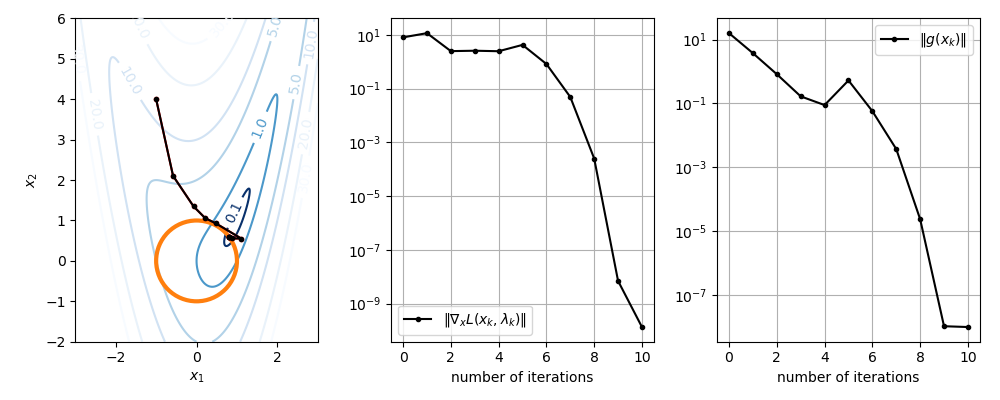

In [22]:
# Close any prior figures
plt.close('Solution path for equality-constrained minimization')

# Extract solution path from log
x_iters = log['x']
res_iters = log['res']

# Figure
fig, (ax2d, ax_res_gradL, ax_res_g) = plt.subplots(
    1, 3, figsize=(10, 4), tight_layout=True,
    num='Solution path for equality-constrained minimization',
)

# Cost
x1_bnds = [-3, 3]
x2_bnds = [-2, 6]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='Blues_r')
ax2d.clabel(CS, fontsize=10)

# Constraint circle
circ = plt.Circle((params['c_x1'], params['c_x2']), params['c_r'], color='C1', fill=False, linewidth=3, zorder=2)
ax2d.add_patch(circ)

# Residuals
ax_res_gradL.semilogy(res_iters[:, 0], color='black', label=r'$\|\nabla_x L(x_k, \lambda_k)\|$', marker='.', markersize=6)
ax_res_g.semilogy(res_iters[:, 1], color='black', label=r'$\|g(x_k)\|$', marker='.', markersize=6)

# Appearance
ax2d.grid()
ax2d.plot(x_iters[:, 0], x_iters[:, 1], 'r.-', markersize=6)
ax2d.plot(x_iters[:, 0], x_iters[:, 1], '.-', color='black', markersize=6)
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
ax_res_gradL.grid()
ax_res_gradL.legend()
ax_res_gradL.set_xlabel('number of iterations')
ax_res_g.grid()
ax_res_g.legend()
ax_res_g.set_xlabel('number of iterations')
plt.show()